# 數值穩定性和模型初始化
:label:`sec_numerical_stability`

到目前为止，我們實現的每個模型都是根據某個預先指定的分布來初始化模型的參數。
有人會認為初始化方案是理所當然的，忽略了如何做出這些選擇的細節。甚至有人可能會覺得，初始化方案的選擇並不是特別重要。
相反，初始化方案的選擇在神經網路學習中起著舉足輕重的地位，
它對保持數值穩定性至關重要。
此外，這些初始化方案的選擇可以與非線性激活函數的選擇有趣的結合在一起。
我們選擇哪個函數以及如何初始化參數可以決定優化算法收斂的速度有多快。
糟糕的選擇可能會導致我們在訓練時遇到梯度爆炸或梯度消失。
本節將更詳細地探討這些主題，並討論一些有用的啟發式方法。
這些啟發式方法在整個深度學習生涯中都很有用。

## 梯度消失和梯度爆炸

考慮一個具有$L$層、輸入$\mathbf{x}$和輸出$\mathbf{o}$的深層網路。
每一層$l$由變換$f_l$定義，
該變換的參數為權重$\mathbf{W}^{(l)}$，
其隱藏變量是$\mathbf{h}^{(l)}$（令 $\mathbf{h}^{(0)} = \mathbf{x}$）。
我們的網路可以表示為：

$$\mathbf{h}^{(l)} = f_l (\mathbf{h}^{(l-1)}) \text{ 因此 } \mathbf{o} = f_L \circ \ldots \circ f_1(\mathbf{x}).$$

如果所有隱藏變量和輸入都是向量，
我們可以將$\mathbf{o}$關於任何一組參數$\mathbf{W}^{(l)}$的梯度寫為下式：

$$\partial_{\mathbf{W}^{(l)}} \mathbf{o} = \underbrace{\partial_{\mathbf{h}^{(L-1)}} \mathbf{h}^{(L)}}_{ \mathbf{M}^{(L)} \stackrel{\mathrm{def}}{=}} \cdot \ldots \cdot \underbrace{\partial_{\mathbf{h}^{(l)}} \mathbf{h}^{(l+1)}}_{ \mathbf{M}^{(l+1)} \stackrel{\mathrm{def}}{=}} \underbrace{\partial_{\mathbf{W}^{(l)}} \mathbf{h}^{(l)}}_{ \mathbf{v}^{(l)} \stackrel{\mathrm{def}}{=}}.$$

換言之，該梯度是$L-l$個矩陣
$\mathbf{M}^{(L)} \cdot \ldots \cdot \mathbf{M}^{(l+1)}$
與梯度向量 $\mathbf{v}^{(l)}$的乘積。
因此，我們容易受到數值下溢問題的影響.
當將太多的概率乘在一起時，這些問題經常會出現。
在處理概率時，一個常見的技巧是切換到對數空間，
即將數值表示的壓力從尾數轉移到指數。
不幸的是，上面問題更為嚴重：
最初，矩陣 $\mathbf{M}^{(l)}$ 可能具有各種各樣的特徵值。
他們可能很小，也可能很大；
他們的乘積可能非常大，也可能非常小。

不穩定梯度帶來的風險不止在於數值表示；
不穩定梯度也威脅到我們優化算法的穩定性。
我們可能面臨一些問題。
要麼是*梯度爆炸*（gradient exploding）問題：
參數更新過大，破壞了模型的穩定收斂；
要麼是*梯度消失*（gradient vanishing）問題：
參數更新過小，在每次更新時幾乎不會移動，導致模型無法學習。

### (**梯度消失**)

曾經sigmoid函數$1/(1 + \exp(-x))$（ :numref:`sec_mlp`提到過）很流行，
因為它類似於閾值函數。
由於早期的人工神經網路受到生物神經網路的啟發，
神經元要么完全激活要么完全不激活（就像生物神經元）的想法很有吸引力。
然而，它卻是導致梯度消失問題的一個常見的原因，
讓我們仔細看看sigmoid函數為什麼會導致梯度消失。


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


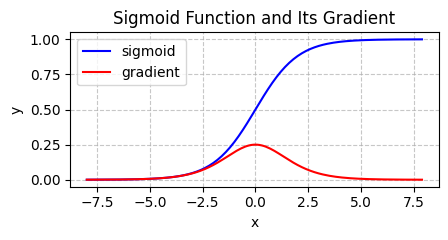

In [1]:
%matplotlib inline
import torch

x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.sigmoid(x)
y.backward(torch.ones_like(x))

import matplotlib.pyplot as plt

plt.figure(figsize=(4.5, 2.5))

# 繪製曲線
plt.plot(x.detach().numpy(), y.detach().numpy(), label='sigmoid', color='blue')
plt.plot(x.detach().numpy(), x.grad.numpy(), label='gradient', color='red')

# 添加標籤和標題
plt.xlabel('x')
plt.ylabel('y')
plt.title('Sigmoid Function and Its Gradient')

# 添加圖例
plt.legend()

# 添加網格
plt.grid(True, linestyle='--', alpha=0.7)

# 調整布局
plt.tight_layout()

# 顯示圖形
plt.show()

正如上圖，當sigmoid函數的輸入很大或是很小時，它的梯度都會消失。
此外，當反向傳播通過許多層時，除非我們在剛剛好的地方，
這些地方sigmoid函數的輸入接近於零，否則整個乘積的梯度可能會消失。
當我們的網路有很多層時，除非我們很小心，否則在某一層可能會切斷梯度。
事實上，這個問題曾經困擾著深度網路的訓練。
因此，更穩定的ReLU系列函數已經成為從業者的默認選擇（雖然在神經科學的角度看起來不太合理）。

### [**梯度爆炸**]

相反，梯度爆炸可能同樣令人煩惱。
為了更好地說明這一點，我們生成100個高斯隨機矩陣，並將它們與某個初始矩陣相乘。
對於我們選擇的尺度（方差$\sigma^2=1$），矩陣乘積發生爆炸。
當這種情況是由深度網路的初始化所導致時，我們沒有機會讓梯度下降優化器收斂。


In [2]:
M = torch.normal(0, 1, size=(4,4))
print('一個矩陣 \n',M)
for i in range(100):
    M = torch.mm(M,torch.normal(0, 1, size=(4, 4)))

print('乘以100個矩陣後\n', M)

一個矩陣 
 tensor([[ 0.9195,  0.1314,  1.0453, -0.7709],
        [-0.9021,  0.8384, -0.8901, -0.4416],
        [-0.3273, -0.9242, -0.1249,  1.5414],
        [ 1.3326,  0.4540,  0.6435, -0.3928]])
乘以100個矩陣後
 tensor([[-2.8670e+21, -5.8185e+21,  2.2624e+21,  8.3280e+21],
        [ 4.3173e+21,  8.7618e+21, -3.4069e+21, -1.2541e+22],
        [ 1.6485e+21,  3.3456e+21, -1.3009e+21, -4.7885e+21],
        [-9.4715e+21, -1.9222e+22,  7.4743e+21,  2.7513e+22]])


### 打破對稱性

神經網路設計中的另一個問題是其參數化所固有的對稱性。
假設我們有一個簡單的多層感知機，它有一個隱藏層和兩個隱藏單元。
在這種情況下，我們可以對第一層的權重$\mathbf{W}^{(1)}$進行重排列，
並且同樣對輸出層的權重進行重排列，可以獲得相同的函數。
第一個隱藏單元與第二個隱藏單元沒有什麼特別的區別。
換句話說，我們在每一層的隱藏單元之間具有排列對稱性。

假設輸出層將上述兩個隱藏單元的多層感知機轉換為僅一個輸出單元。
想象一下，如果我們將隱藏層的所有參數初始化為$\mathbf{W}^{(1)} = c$，
$c$為常量，會發生什麼？
在這種情況下，在前向傳播期間，兩個隱藏單元採用相同的輸入和參數，
產生相同的激活，該激活被送到輸出單元。
在反向傳播期間，根據參數$\mathbf{W}^{(1)}$對輸出單元進行微分，
得到一個梯度，其元素都取相同的值。
因此，在基於梯度的迭代（例如，小批量隨機梯度下降）之後，
$\mathbf{W}^{(1)}$的所有元素仍然採用相同的值。
這樣的迭代永遠不會打破對稱性，我們可能永遠也無法實現網路的表達能力。
隱藏層的行為就好像只有一個單元。
請注意，雖然小批量隨機梯度下降不會打破這種對稱性，但暫退法正則化可以。

## 參數初始化

解決（或至少減輕）上述問題的一種方法是進行參數初始化，
優化期間的注意和適當的正則化也可以進一步提高穩定性。

### 預設初始化

在前面的部分中，例如在 :numref:`sec_linear_concise`中，
我們使用正態分布來初始化權重值。如果我們不指定初始化方法，
框架將使用預設的隨機初始化方法，對於中等難度問題，這種方法通常很有效。

### Xavier初始化
:label:`subsec_xavier`

讓我們看看某些*沒有非線性*的全連接層輸出（例如，隱藏變量）$o_{i}$的尺度分布。
對於該層$n_\mathrm{in}$輸入$x_j$及其相關權重$w_{ij}$，輸出由下式給出

$$o_{i} = \sum_{j=1}^{n_\mathrm{in}} w_{ij} x_j.$$

權重$w_{ij}$都是從同一分布中獨立抽取的。
此外，讓我們假設該分布具有零均值和方差$\sigma^2$。
請注意，這並不意味著分布必須是高斯的，只是均值和方差需要存在。
現在，讓我們假設層$x_j$的輸入也具有零均值和方差$\gamma^2$，
並且它們獨立於$w_{ij}$並且彼此獨立。
在這種情況下，我們可以按如下方式計算$o_i$的平均值和方差：

$$
\begin{aligned}
    E[o_i] & = \sum_{j=1}^{n_\mathrm{in}} E[w_{ij} x_j] \\&= \sum_{j=1}^{n_\mathrm{in}} E[w_{ij}] E[x_j] \\&= 0, \\
    \mathrm{Var}[o_i] & = E[o_i^2] - (E[o_i])^2 \\
        & = \sum_{j=1}^{n_\mathrm{in}} E[w^2_{ij} x^2_j] - 0 \\
        & = \sum_{j=1}^{n_\mathrm{in}} E[w^2_{ij}] E[x^2_j] \\
        & = n_\mathrm{in} \sigma^2 \gamma^2.
\end{aligned}
$$

保持方差不變的一種方法是設置$n_\mathrm{in} \sigma^2 = 1$。
現在考慮反向傳播過程，我們面臨著類似的問題，儘管梯度是從更靠近輸出的層傳播的。
使用與前向傳播相同的推斷，我們可以看到，除非$n_\mathrm{out} \sigma^2 = 1$，
否則梯度的方差可能會增大，其中$n_\mathrm{out}$是該層的輸出的數量。
這使得我們進退兩難：我們不可能同時滿足這兩個條件。
相反，我們只需滿足：

$$
\begin{aligned}
\frac{1}{2} (n_\mathrm{in} + n_\mathrm{out}) \sigma^2 = 1 \text{ 或等价于 }
\sigma = \sqrt{\frac{2}{n_\mathrm{in} + n_\mathrm{out}}}.
\end{aligned}
$$

這就是現在標準且實用的*Xavier初始化*的基礎，
它以其提出者 :cite:`Glorot.Bengio.2010` 第一作者的名字命名。
通常，Xavier初始化從均值為零，方差
$\sigma^2 = \frac{2}{n_\mathrm{in} + n_\mathrm{out}}$
的高斯分布中采樣權重。
我們也可以將其改為選擇從均勻分布中抽取權重時的方差。
注意均勻分布$U(-a, a)$的方差為$\frac{a^2}{3}$。
將$\frac{a^2}{3}$代入到$\sigma^2$的條件中，將得到初始化值域：

$$U\left(-\sqrt{\frac{6}{n_\mathrm{in} + n_\mathrm{out}}}, \sqrt{\frac{6}{n_\mathrm{in} + n_\mathrm{out}}}\right).$$

儘管在上述數學推理中，“不存在非線性”的假設在神經網路中很容易被違反，
但Xavier初始化方法在實踐中被證明是有效的。

### 額外閱讀

上面的推理僅僅觸及了現代參數初始化方法的皮毛。
深度學習框架通常實現了十幾種不同的啟發式方法。
此外，參數初始化一直是深度學習基礎研究的重點領域。
其中包括專門用於參數繫結（共享）、超分辨率、序列模型和其他情況的啟發式算法。
例如，Xiao等人演示了通過使用精心設計的初始化方法
 :cite:`Xiao.Bahri.Sohl-Dickstein.ea.2018`，
可以無須架構上的技巧而訓練10000層神經網路的可能性。

如果有讀者對該主題感興趣，我們建議深入研究本模塊的內容，
閱讀提出並分析每種啟發式方法的論文，然後探索有關該主題的最新出版物。
也許會偶然發現甚至發明一個聰明的想法，並為深度學習框架提供一個實現。

## 小結

* 梯度消失和梯度爆炸是深度網路中常見的問題。在參數初始化時需要非常小心，以確保梯度和參數可以得到很好的控制。
* 需要用啟發式的初始化方法來確保初始梯度既不太大也不太小。
* ReLU激活函數緩解了梯度消失問題，這樣可以加速收斂。
* 隨機初始化是保證在進行優化前打破對稱性的關鍵。
* Xavier初始化表明，對於每一層，輸出的方差不受輸入數量的影響，任何梯度的方差不受輸出數量的影響。

## 練習

1. 除了多層感知機的排列對稱性之外，還能設計出其他神經網路可能會表現出對稱性且需要被打破的情況嗎？
2. 我們是否可以將線性回歸或softmax回歸中的所有權重參數初始化為相同的值？
3. 在相關資料中查找兩個矩陣乘積特徵值的解析界。這對確保梯度條件合適有什麼啟示？
4. 如果我們知道某些項是發散的，我們能在事後修正嗎？看看關於按層自適應速率縮放的論文 :cite:`You.Gitman.Ginsburg.2017` 。


## 練習一

1. 除了多層感知機的排列對稱性之外，還能設計出其他神經網路可能會表現出對稱性且需要被打破的情況嗎？

回答：



是的，讓我們探討一些其他神經網路中的對稱性情況：

1. **循環神經網路(RNN)中的對稱性**：
```python
class SymmetricRNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        # 如果初始化相同，前向和循環權重將產生對稱性
        self.W_forward = nn.Linear(input_size, hidden_size)
        self.W_recurrent = nn.Linear(hidden_size, hidden_size)
        
    def forward(self, x, h):
        # h_new = σ(W_forward * x + W_recurrent * h)
        # 如果W_forward和W_recurrent初始化相同，會導致對稱性
        return torch.tanh(self.W_forward(x) + self.W_recurrent(h))
```

2. **自注意力機制中的對稱性**：
```python
class SymmetricAttention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        # Q, K, V矩陣如果初始化相同，會導致注意力權重對稱
        self.Q = nn.Linear(dim, dim)
        self.K = nn.Linear(dim, dim)
        self.V = nn.Linear(dim, dim)
        
    def forward(self, x):
        # 如果Q=K=V，所有位置會得到相同的注意力分數
        q = self.Q(x)
        k = self.K(x)
        v = self.V(x)
        scores = torch.matmul(q, k.transpose(-2, -1))
        return torch.matmul(F.softmax(scores, dim=-1), v)
```

3. **卷積神經網路(CNN)中的對稱性**：
```python
class SymmetricCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # 多個相同的卷積核會導致特徵圖對稱
        self.conv = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        
    def forward(self, x):
        # 如果所有卷積核初始化相同，會提取相同的特徵
        return self.conv(x)
```

4. **圖神經網路(GNN)中的對稱性**：
```python
class SymmetricGNN(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        # 如果所有節點的轉換矩陣相同，會導致節點表示對稱
        self.transform = nn.Linear(in_features, out_features)
        
    def forward(self, x, adj):
        # 所有節點會得到相同的更新
        h = self.transform(x)
        return torch.matmul(adj, h)
```

5. **打破對稱性的方法**：

a) **非對稱初始化**：
```python
def asymmetric_init(module):
    if isinstance(module, nn.Linear):
        # 使用不同的初始化方法
        nn.init.xavier_normal_(module.weight)
        # 添加小的隨機擾動
        module.weight.data += torch.randn_like(module.weight.data) * 0.01
```

b) **添加噪聲**：
```python
class NoiseLayer(nn.Module):
    def __init__(self, sigma=0.01):
        super().__init__()
        self.sigma = sigma
        
    def forward(self, x):
        if self.training:
            return x + torch.randn_like(x) * self.sigma
        return x
```

c) **使用不同的激活函數**：
```python
class AsymmetricNet(nn.Module):
    def __init__(self):
        super().__init__()
        # 使用不同的激活函數
        self.activations = [
            nn.ReLU(),
            nn.LeakyReLU(),
            nn.GELU(),
            nn.SiLU()
        ]
```

6. **實際應用中的建議**：

```python
class RobustNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # 1. 使用不同的初始化
        self.layer1 = nn.Linear(784, 256)
        self.layer2 = nn.Linear(256, 256)
        nn.init.xavier_normal_(self.layer1.weight)
        nn.init.kaiming_normal_(self.layer2.weight)
        
        # 2. 添加噪聲層
        self.noise = NoiseLayer(0.01)
        
        # 3. 使用不同的激活函數
        self.act1 = nn.ReLU()
        self.act2 = nn.GELU()
        
    def forward(self, x):
        x = self.noise(self.act1(self.layer1(x)))
        x = self.act2(self.layer2(x))
        return x
```

這些對稱性問題的解決方案有助於：
1. 提高模型的表達能力
2. 加速訓練收斂
3. 避免梯度消失/爆炸
4. 提升模型的泛化能力

在實際應用中，應該：
- 注意識別潛在的對稱性
- 使用適當的初始化方法
- 考慮添加適當的噪聲或擾動
- 監控訓練過程中的對稱性指標


## 練習二

我們是否可以將線性回歸或softmax回歸中的所有權重參數初始化為相同的值？

回答：

不建議將線性回歸或softmax回歸中的所有權重初始化為相同的值，讓我解釋原因：

1. **線性回歸的情況**：
````python
class LinearRegression(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        # 不好的初始化方式
        bad_init = torch.ones(input_dim, 1) * 0.1  # 所有權重都是0.1
        self.linear = nn.Linear(input_dim, 1)
        
        # 更好的初始化方式
        good_init = torch.randn(input_dim, 1) * np.sqrt(2.0/input_dim)  # Xavier初始化
````

問題：
1. 所有特徵會有相同的影響力
2. 模型無法學習特徵間的相對重要性
3. 梯度更新會完全相同

2. **Softmax回歸的情況**：
````python
class SoftmaxRegression(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        # 不好的初始化
        bad_weights = torch.ones(input_dim, num_classes) * 0.1
        
        # 更好的初始化
        self.linear = nn.Linear(input_dim, num_classes)
        nn.init.xavier_normal_(self.linear.weight)
````

問題：
1. 所有類別會得到相同的初始預測
2. 破壞了多類別分類的本質
3. 減慢收斂速度

3. **實驗演示**：
````python
def compare_initializations():
    # 生成示例數據
    X = torch.randn(1000, 10)
    y = torch.randint(0, 3, (1000,))
    
    # 相同值初始化
    model1 = nn.Linear(10, 3)
    model1.weight.data.fill_(0.1)
    
    # 隨機初始化
    model2 = nn.Linear(10, 3)
    nn.init.xavier_normal_(model2.weight)
    
    # 比較初始預測
    pred1 = F.softmax(model1(X), dim=1)
    pred2 = F.softmax(model2(X), dim=1)
    
    print("相同值初始化的預測分布：")
    print(pred1[0])  # 所有類別概率相同
    
    print("\n隨機初始化的預測分布：")
    print(pred2[0])  # 不同類別有不同的初始概率
````

4. **為什麼需要不同的初始值**：

a) **特徵重要性**：
````python
# 特徵可能有不同的重要性
important_feature = X[:, 0] * 2.0  # 第一個特徵更重要
less_important_feature = X[:, 1] * 0.5  # 第二個特徵不太重要

# 如果權重相同，無法反映這種差異
same_weights = torch.ones(X.shape[1]) * 0.1
predictions = (X * same_weights).sum(dim=1)
````

b) **梯度更新**：
````python
def demonstrate_gradient_update():
    # 相同權重的情況
    w_same = torch.ones(5) * 0.1
    w_same.requires_grad = True
    
    # 計算損失和梯度
    x = torch.randn(5)
    y = torch.randn(1)
    
    pred = (w_same * x).sum()
    loss = (pred - y) ** 2
    loss.backward()
    
    print("相同權重的梯度：")
    print(w_same.grad)  # 梯度只與輸入值成比例
````

5. **建議的初始化策略**：
````python
def proper_initialization(model):
    if isinstance(model, nn.Linear):
        # 使用Xavier初始化
        fan_in = model.weight.size(1)
        nn.init.normal_(model.weight, 0, np.sqrt(2.0/fan_in))
        
        # 偏置項初始化為0
        if model.bias is not None:
            nn.init.zeros_(model.bias)
````

6. **實際應用中的注意事項**：
- 使用合適的初始化方法（如Xavier或Kaiming初始化）
- 考慮特徵的尺度和重要性
- 監控訓練初期的行為
- 必要時進行特徵標準化

總結：
1. 相同值初始化會導致：
   - 特徵重要性無法區分
   - 梯度更新效率低
   - 訓練收斂緩慢
2. 應該使用合適的隨機初始化方法
3. 初始化對模型訓練的成功至關重要


## 練習三

在相關資料中查找兩個矩陣乘積特徵值的解析界。這對確保梯度條件合適有什麼啟示？

回答：

讓我們分析矩陣乘積的特徵值界限及其對梯度的影響：

1. **矩陣乘積特徵值的界限**：

對於兩個矩陣 A 和 B，其乘積 AB 的特徵值 λ 滿足：
`````python
import numpy as np

def eigenvalue_bounds(A, B):
    # 計算矩陣乘積的特徵值界限
    sigma_min_A = np.min(np.linalg.svd(A)[1])  # A的最小奇異值
    sigma_max_A = np.max(np.linalg.svd(A)[1])  # A的最大奇異值
    sigma_min_B = np.min(np.linalg.svd(B)[1])  # B的最小奇異值
    sigma_max_B = np.max(np.linalg.svd(B)[1])  # B的最大奇異值
    
    # 乘積的特徵值界限
    lower_bound = sigma_min_A * sigma_min_B
    upper_bound = sigma_max_A * sigma_max_B
    
    return lower_bound, upper_bound
`````

2. **對梯度條件的啟示**：

a) **梯度消失問題**：
`````python
def check_gradient_vanishing(W1, W2):
    # 檢查是否可能發生梯度消失
    _, upper_bound = eigenvalue_bounds(W1, W2)
    
    if upper_bound < 0.1:  # 設定閾值
        print("警告：可能發生梯度消失")
        print(f"特徵值上界：{upper_bound}")
        
        # 建議的修正
        scale = np.sqrt(1.0 / upper_bound)
        return W1 * scale, W2 * scale
    return W1, W2
`````

b) **梯度爆炸問題**：
`````python
def check_gradient_explosion(W1, W2):
    # 檢查是否可能發生梯度爆炸
    _, upper_bound = eigenvalue_bounds(W1, W2)
    
    if upper_bound > 10:  # 設定閾值
        print("警告：可能發生梯度爆炸")
        print(f"特徵值上界：{upper_bound}")
        
        # 建議的修正
        scale = np.sqrt(1.0 / upper_bound)
        return W1 * scale, W2 * scale
    return W1, W2
`````

3. **實際應用中的初始化策略**：

`````python
class StableNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        
        # 使用Xavier初始化來控制特徵值範圍
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, output_dim)
        
        # 初始化權重
        nn.init.xavier_normal_(self.layer1.weight)
        nn.init.xavier_normal_(self.layer2.weight)
        
        # 檢查特徵值條件
        W1 = self.layer1.weight.detach().numpy()
        W2 = self.layer2.weight.detach().numpy()
        
        lower, upper = eigenvalue_bounds(W1, W2)
        print(f"初始特徵值範圍：[{lower:.4f}, {upper:.4f}]")
`````

4. **監控和調整機制**：

`````python
class GradientMonitor:
    def __init__(self, model, threshold=10.0):
        self.model = model
        self.threshold = threshold
        
    def check_gradients(self):
        total_norm = 0
        for p in self.model.parameters():
            if p.grad is not None:
                param_norm = p.grad.data.norm(2)
                total_norm += param_norm.item() ** 2
        total_norm = total_norm ** 0.5
        
        if total_norm > self.threshold:
            print(f"警告：梯度範數 ({total_norm:.2f}) 超過閾值 {self.threshold}")
            return False
        return True
`````

5. **實踐建議**：

a) **初始化時**：
- 使用Xavier或Kaiming初始化
- 檢查權重矩陣的條件數
- 確保特徵值在合理範圍內

b) **訓練過程中**：
- 監控梯度範數
- 使用梯度裁剪
- 適時調整學習率

6. **具體實現示例**：

`````python
def initialize_network(input_dim, hidden_dim, output_dim):
    # 創建模型
    model = StableNetwork(input_dim, hidden_dim, output_dim)
    
    # 設置梯度監控器
    monitor = GradientMonitor(model)
    
    # 訓練循環
    def training_step(x, y):
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        
        # 檢查梯度條件
        if monitor.check_gradients():
            optimizer.step()
        else:
            # 執行梯度裁剪或調整學習率
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
    
    return model, training_step
`````

這些分析和實現的主要啟示：

1. **初始化重要性**：
   - 合適的初始化可以防止梯度問題
   - 需要考慮網絡深度的影響
   - 特徵值範圍直接影響訓練穩定性

2. **監控機制**：
   - 定期檢查梯度條件
   - 及時發現並處理問題
   - 自適應調整策略

3. **優化策略**：
   - 結合梯度裁剪
   - 使用自適應學習率
   - 考慮層級正則化

這些理論界限和實踐策略有助於設計更穩定、更容易訓練的神經網絡。

## 練習四

如果我們知道某些項是發散的，我們能在事後修正嗎？看看關於按層自適應速率縮放的論文 :cite:`You.Gitman.Ginsburg.2017` 。

回答：



讓我們探討如何在事後修正發散問題，並實現按層自適應速率縮放（Layer-wise Adaptive Rate Scaling, LARS）：

1. **LARS 的基本實現**：

``````python
class LARS(torch.optim.Optimizer):
    def __init__(self, params, lr=1e-3, trust_coefficient=0.001, eps=1e-8):
        defaults = dict(lr=lr, trust_coefficient=trust_coefficient, eps=eps)
        super(LARS, self).__init__(params, defaults)
        
    def step(self):
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue
                    
                # 計算參數和梯度的L2範數
                param_norm = torch.norm(p.data)
                grad_norm = torch.norm(p.grad.data)
                
                # 計算自適應學習率
                adaptive_lr = group['lr']
                
                if param_norm > 0 and grad_norm > 0:
                    # LARS 自適應係數
                    local_lr = group['trust_coefficient'] * (param_norm / (grad_norm + group['eps']))
                    adaptive_lr *= local_lr
                
                # 更新參數
                p.data.add_(p.grad.data, alpha=-adaptive_lr)
``````

2. **發散檢測和修正機制**：

``````python
class DivergenceCorrector:
    def __init__(self, model, threshold=10.0):
        self.model = model
        self.threshold = threshold
        self.layer_stats = {}
        
    def check_and_correct(self):
        with torch.no_grad():
            for name, param in self.model.named_parameters():
                # 檢查參數值是否發散
                if torch.isnan(param).any() or torch.isinf(param).any():
                    print(f"檢測到層 {name} 發散")
                    self.correct_layer(name, param)
                    
                # 記錄層統計信息
                self.layer_stats[name] = {
                    'norm': torch.norm(param).item(),
                    'mean': param.mean().item(),
                    'std': param.std().item()
                }
    
    def correct_layer(self, name, param):
        # 使用最後的有效統計信息重新初始化
        if name in self.layer_stats:
            stats = self.layer_stats[name]
            # 使用之前的統計信息重新初始化
            param.data = torch.randn_like(param) * stats['std'] + stats['mean']
        else:
            # 使用默認初始化
            nn.init.xavier_normal_(param)
``````

3. **自適應學習率調整**：

``````python
class AdaptiveLearningRateScheduler:
    def __init__(self, optimizer, init_lr=0.1):
        self.optimizer = optimizer
        self.init_lr = init_lr
        self.layer_lrs = {}
        
    def adjust_learning_rates(self, model):
        for name, param in model.named_parameters():
            if param.grad is not None:
                # 計算梯度範數
                grad_norm = torch.norm(param.grad)
                param_norm = torch.norm(param)
                
                # 根據梯度和參數範數調整學習率
                if name not in self.layer_lrs:
                    self.layer_lrs[name] = self.init_lr
                
                # 自適應調整
                if grad_norm > 0:
                    lr_multiplier = min(1.0, param_norm / grad_norm)
                    self.layer_lrs[name] *= lr_multiplier
                
                # 應用新的學習率
                for group in self.optimizer.param_groups:
                    if param in group['params']:
                        group['lr'] = self.layer_lrs[name]
``````

4. **整合訓練流程**：

``````python
class AdaptiveTrainer:
    def __init__(self, model, optimizer, criterion):
        self.model = model
        self.optimizer = optimizer
        self.criterion = criterion
        self.corrector = DivergenceCorrector(model)
        self.lr_scheduler = AdaptiveLearningRateScheduler(optimizer)
        
    def train_step(self, x, y):
        # 前向傳播
        outputs = self.model(x)
        loss = self.criterion(outputs, y)
        
        # 反向傳播
        self.optimizer.zero_grad()
        loss.backward()
        
        # 檢查和修正發散
        self.corrector.check_and_correct()
        
        # 調整學習率
        self.lr_scheduler.adjust_learning_rates(self.model)
        
        # 更新參數
        self.optimizer.step()
        
        return loss.item()
``````

5. **使用示例**：

``````python
def train_with_correction(model, train_loader, num_epochs=10):
    optimizer = LARS(model.parameters())
    criterion = nn.CrossEntropyLoss()
    trainer = AdaptiveTrainer(model, optimizer, criterion)
    
    for epoch in range(num_epochs):
        for batch_idx, (data, target) in enumerate(train_loader):
            loss = trainer.train_step(data, target)
            
            if batch_idx % 100 == 0:
                print(f'Epoch: {epoch}, Batch: {batch_idx}, Loss: {loss:.4f}')
                
                # 打印每層的學習率
                for name, param in model.named_parameters():
                    if name in trainer.lr_scheduler.layer_lrs:
                        print(f'Layer {name} lr: {trainer.lr_scheduler.layer_lrs[name]:.6f}')
``````

6. **監控和可視化**：

``````python
class TrainingMonitor:
    def __init__(self):
        self.stats = defaultdict(list)
        
    def update(self, trainer):
        # 記錄每層的統計信息
        for name, param in trainer.model.named_parameters():
            self.stats[f'{name}_norm'].append(torch.norm(param).item())
            if name in trainer.lr_scheduler.layer_lrs:
                self.stats[f'{name}_lr'].append(trainer.lr_scheduler.layer_lrs[name])
    
    def plot_stats(self):
        plt.figure(figsize=(12, 6))
        
        # 繪製參數範數變化
        plt.subplot(1, 2, 1)
        for name in self.stats:
            if name.endswith('_norm'):
                plt.plot(self.stats[name], label=name)
        plt.title('Parameter Norms')
        plt.legend()
        
        # 繪製學習率變化
        plt.subplot(1, 2, 2)
        for name in self.stats:
            if name.endswith('_lr'):
                plt.plot(self.stats[name], label=name)
        plt.title('Learning Rates')
        plt.legend()
        
        plt.tight_layout()
        plt.show()
``````

這種方法的主要優點：
1. 自動檢測和修正發散問題
2. 為每一層提供自適應學習率
3. 保持訓練穩定性
4. 提供詳細的監控和可視化

注意事項：
1. 需要定期備份模型參數
2. 監控修正的頻率和閾值
3. 考慮計算開銷
4. 可能需要根據具體任務調整超參數



[Discussions](https://discuss.d2l.ai/t/1818)
